## load packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

print(os.getcwd())

/home/jovyan/sp25-student/grad-proj/nlp-chatbot-analysis


In [3]:
import warnings
warnings.filterwarnings('ignore')

## load data

In [4]:
dat = pd.read_csv('complete_data_for_tasks_deciphered.csv')

print(dat.shape)
dat.head(5)

(25256, 16)


,prompt,topic_modeling_1,score_reason_1,score_value_1,topic_modeling_2,score_reason_2,score_value_2,topic_modeling_3,score_reason_3,score_value_3,topic_modeling_1_cluster,topic_modeling_2_cluster,topic_modeling_3_cluster,model_a,model_b,winner
0,What is the difference between OpenCL and CUDA?,Technical Comparison,This prompt requires the AI to accurately comp...,9,Software Comparison,This prompt assesses the AI's factual accuracy...,8,"Comparison, Technology",This prompt requires the AI to demonstrate kno...,9,"Comparison, Time","Technology, Engineering","Comparison, Time",chatglm-6b,koala-13b,model_b
1,Why did my parent not invite me to their wedding?,"Reasoning, Emotion",This prompt requires the AI to understand huma...,9,"Emotions, Relationships",This prompt involves understanding complex hum...,8,"Reasoning, Emotional",This prompt challenges the AI to infer motives...,8,"Emotional, Psychology","Emotional, Psychology","Emotional, Psychology",oasst-pythia-12b,alpaca-13b,tie
2,"Fuji vs. Nikon, which is better?",Camera comparison,This prompt does not require problem-solving s...,2,Comparative Analysis,This prompt assesses the AI's ability to analy...,6,Photography comparison,This prompt is subjective and does not provide...,2,"Identification, Classification","Comparison, Time","Identification, Classification",koala-13b,oasst-pythia-12b,model_b
3,How to build an arena for chatbots?,Chatbot Arena,This prompt requires problem-solving skills an...,8,Chatbot Arena,This prompt requires the AI to engage in probl...,8,Chatbot Arena,This prompt requires problem-solving skills an...,8,"Communication, Chatbot","Communication, Chatbot","Communication, Chatbot",vicuna-13b,oasst-pythia-12b,model_b
4,When is it today?,Time Query,This prompt is very straightforward and does n...,2,Date Inquiry,This prompt is very straightforward and does n...,2,Time-based Inquiry,This prompt is too straightforward and simply ...,2,"Comparison, Time","Comparison, Time","Comparison, Time",vicuna-13b,koala-13b,model_a


## EDA

### number of unique topics in each prompt question topic column (motivation for the cluster model)

In [44]:
temp_dat = pd.DataFrame({
    'y':dat[['topic_modeling_1','topic_modeling_2','topic_modeling_3']].nunique().values.tolist()+[25256, 25256, 25256], 
    'type':['number of unique topics', 'number of unique topics', 'number of unique topics', 'total number of samples', 'total number of samples', 'total number of samples'], 
    'x':['topic_modeling_1','topic_modeling_2','topic_modeling_3','topic_modeling_1','topic_modeling_2','topic_modeling_3']
})

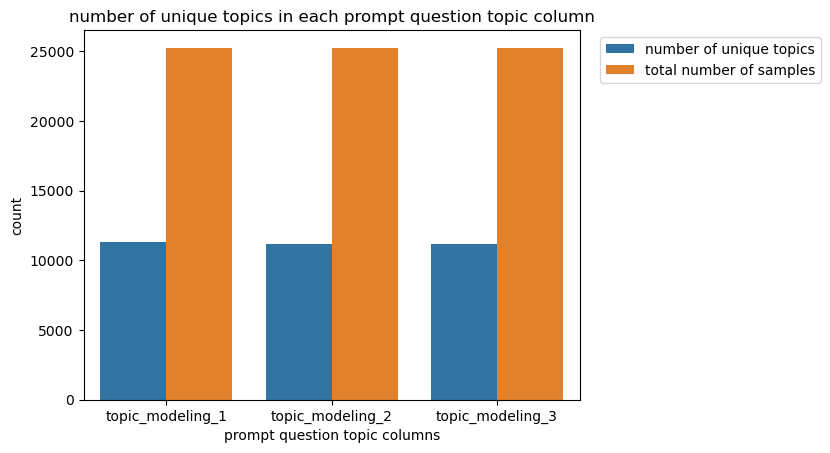

In [45]:
sns.barplot(temp_dat, x='x', y='y', hue='type')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
plt.title('number of unique topics in each prompt question topic column')
plt.xlabel('prompt question topic columns')
plt.ylabel('count')
plt.show()

### task A ground truth label (winner) distribution

Text(0.5, 1.0, 'task A ground truth label (winner) distribution')

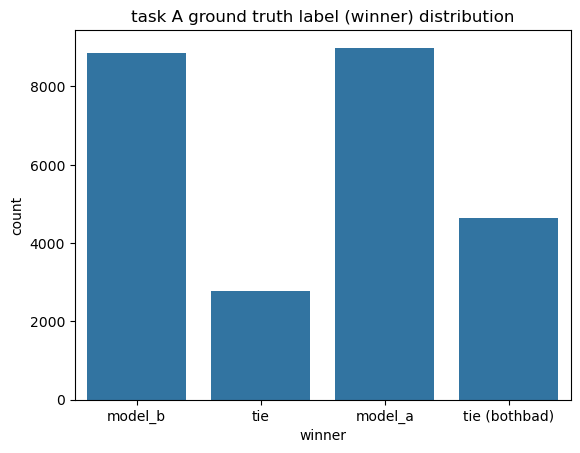

In [46]:
sns.countplot(dat, x='winner')
plt.title('task A ground truth label (winner) distribution')

### task B ground truth label (prompt question hardness score) distribution

Text(0.5, 1.0, 'task B ground truth label (prompt question hardness score) distribution')

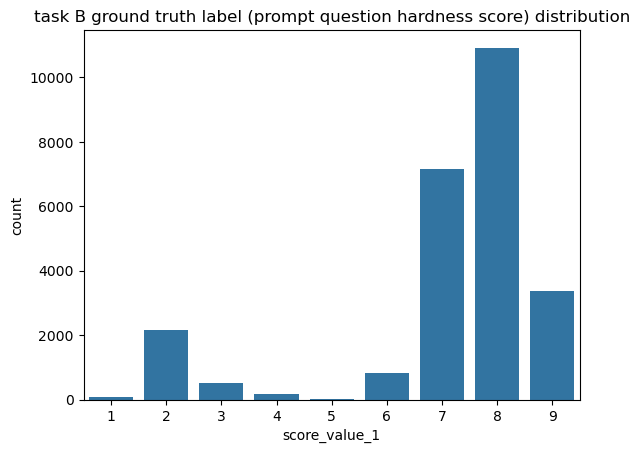

In [47]:
sns.countplot(dat, x='score_value_1')
plt.title('task B ground truth label (prompt question hardness score) distribution')

### win rate for individual LLM models

In [50]:
temp_series = dat.groupby('model_a').apply(lambda df: len(df[df['winner'] == 'model_a']) / len(df))
temp_dat = pd.DataFrame({
    'model':temp_series.index, 
    'win rate':temp_series.values
})

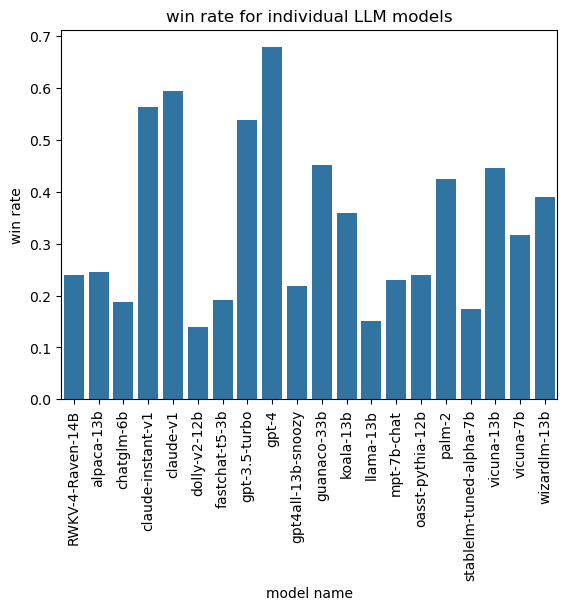

In [54]:
sns.barplot(temp_dat, x='model', y='win rate')
plt.xticks(rotation=90)
plt.xlabel('model name')
plt.title('win rate for individual LLM models')
plt.show()

### average hardness score of each prompt question cluster

In [58]:
temp_dat = dat.groupby('topic_modeling_1_cluster').agg({'score_value_1':'mean'}).reset_index(drop=False)

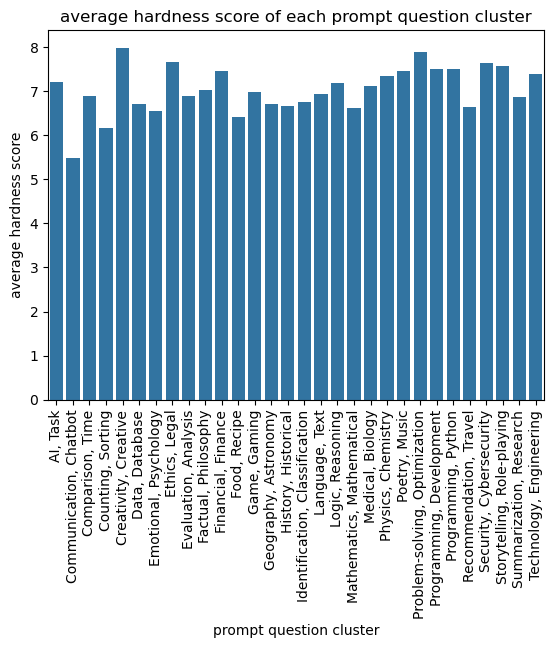

In [62]:
sns.barplot(temp_dat, x='topic_modeling_1_cluster', y='score_value_1')
plt.xticks(rotation=90)
plt.xlabel('prompt question cluster')
plt.ylabel('average hardness score')
plt.title('average hardness score of each prompt question cluster')
plt.show()